<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit con brazos de tipo normal


*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy, softmax y ucb1 en un problema de k-armed bandit con brazos de tipo normal.
Se generan gráficas de recompensas promedio, selección del brazo óptimo, regret acumulado y estadísticas por brazo (una cada vez) para cada algoritmo.

## Preparación del entorno


In [1]:
#@title Importamos todas las clases y funciones

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, Softmax, UCB1
from arms import ArmNormal, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics


## Experimento


Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio, selección del brazo óptimo, regret acumulado y estadísticas de los brazos.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan tres algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recompensas obtenidas en esas 500 veces.

In [2]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regret_accumulated = np.zeros((len(algorithms), steps)) # Matriz de arrepentimiento acumulado

    arm_stats = [
        {
            "reward_sum": np.zeros(len(bandit.arms)), # Suma de premios en cada brazo
            "selections": np.zeros(len(bandit.arms)), # Número de veces que se selecciona cada brazo
            "optimal_arm": bandit.optimal_arm # Número del brazo óptimo
        }
        for _ in algorithms # Lo crea tantas veces por algoritmos tengamos
    ]

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        q_star = current_bandit.get_expected_value(current_bandit.optimal_arm) # q_star es el valor esperado del mejor brazo

        regret_per_run = np.zeros((len(algorithms), steps)) # Matriz de arrepentimiento por run

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                if chosen_arm == optimal_arm: # Si el brazo elegido es el óptimo
                    optimal_selections[idx, step] += 1 # Aumenta en 1 el número de selecciones óptimas en cada paso

                regret = q_star - reward # El arrepentimiento es el valor esperado del mejor brazo - la recompensa del brazo actual

                if step == 0:
                    regret_per_run[idx, step] = regret # En el primer paso cogemos el arrepentimiento actual
                else:
                    regret_per_run[idx, step] = (regret_per_run[idx, step - 1] + regret) # En los siguientes pasos el arrepentimiento el arrepentimiento acumulado más el arrepentimiento del paso actual

                arm_stats[idx]["selections"][chosen_arm] += 1 # Se aumenta el número de selecciones a 1 del brazo elegido por algoritmo
                arm_stats[idx]["reward_sum"][chosen_arm] += reward # Se suma todos los premios del brazo elegido por algoritmo

        regret_accumulated += regret_per_run # Regret acumulado por run

    rewards /= runs # Promedio de las recompensas

    optimal_selections = (optimal_selections / runs) * 100 # Saca el porcentaje de selección óptima de cada algoritmo en cada paso

    regret_accumulated /= runs # Promedio del arrepentimiento

    return rewards, optimal_selections, regret_accumulated, arm_stats


## Ejecución del experimento


Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan:
- Tres algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.
- Tres algoritmos softmax para valores tau: 0.2, 0.5 y 1.0.
- Tres algoritmos UCB1 para valores coeficiente: 0.0, 1.41 y 4.0.

In [3]:

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithmsEpsilon = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Definir los algoritmos a comparar. En este caso son 3 algoritmos Softmax con diferentes valores de tau.
algorithmsSoftmax = [Softmax(k=k, tau=0.2), Softmax(k=k, tau=0.5), Softmax(k=k, tau=1.0)]

# Definir los algoritmos a comparar. En este caso son 3 algoritmos UCB1 con diferentes valores de c.
algorithmsUCB1 = [UCB1(k=k, c=0.0), UCB1(k=k, c=1.41), UCB1(k=k, c=4.0)]

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsEpsilon, optimal_selections_Epsilon, regret_accumulated_Epsilon, arm_stats_Epsilon = run_experiment(bandit, algorithmsEpsilon, steps, runs)

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsSoftmax, optimal_selections_Softmax, regret_accumulated_Softmax, arm_stats_Softmax = run_experiment(bandit, algorithmsSoftmax, steps, runs)

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsUCB1, optimal_selections_UCB1, regret_accumulated_UCB1, arm_stats_UCB1 = run_experiment(bandit, algorithmsUCB1, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


## Visualización de los resultados

Aquí visualizaremos cuatro tipo de gráficas:
- Recompensa promedio con respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Selección de brazo óptimo respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Regrets acumulados respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Estadísticas de cada brazo: 9 gráficas en total, tres por algoritmo, una por parámetro epsilon, tau o coeficiente.

### Análisis previo sobre los 3 primeros tipos de gráficas

En cuanto a las imágenes de los 3 primeros tipos de gráfica tendremos en cuenta lo siguiente:

1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - **Azul (ε = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja (ε = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (ε = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias.

2. **Tres líneas de colores distintos representan diferentes valores de $\tau$ en el algoritmo Softmax:**
   - **Azul ($\tau$ = 0.2):** Representa una estrategia de **temperatura baja**, lo que genera una distribución de probabilidad altamente concentrada en el brazo con mayor valor estimado. Esto hace que el algoritmo tenga un comportamiento **explotador**
   - **Naranja ($\tau$ = 0.5):** Representa una estrategia de **temperatura media**, lo que hace que haya una distribución de probabilidad más equilibrada entre los brazos, adquiriendo un equilibrio de comportamiento **explorador** y **explotador**
   - **Verde ($\tau$ = 1.0):** Representa una estrategia de **temperatura alta**, haciendo que se suavice mucho la diferencia entre valores estimados, haciendo que el algoritmo adquiera un comportamiento mucho más **explorador**.

3. **Tres líneas de colores distintos representan diferentes valores de coeficiente en el algoritmo UCB1:**
   - **Azul (c = 0.0):** Representa una estrategia completamente elitista haciendo que sea **explotadora**, seleccionando únicamente el brazo con mejor valor estimado.
   - **Naranja (c = 1.41):** Representa una estrategia más equilibrada de **exploración** y **explotación**, aumentando la selección de brazos menos visitados.
   - **Verde (c = 4.0):** Representa una estrategia de **exploración** muy alta, haciendo que al algoritmo le de menos importancia al valor estimado e intente seleccionar brazos menos visitados.

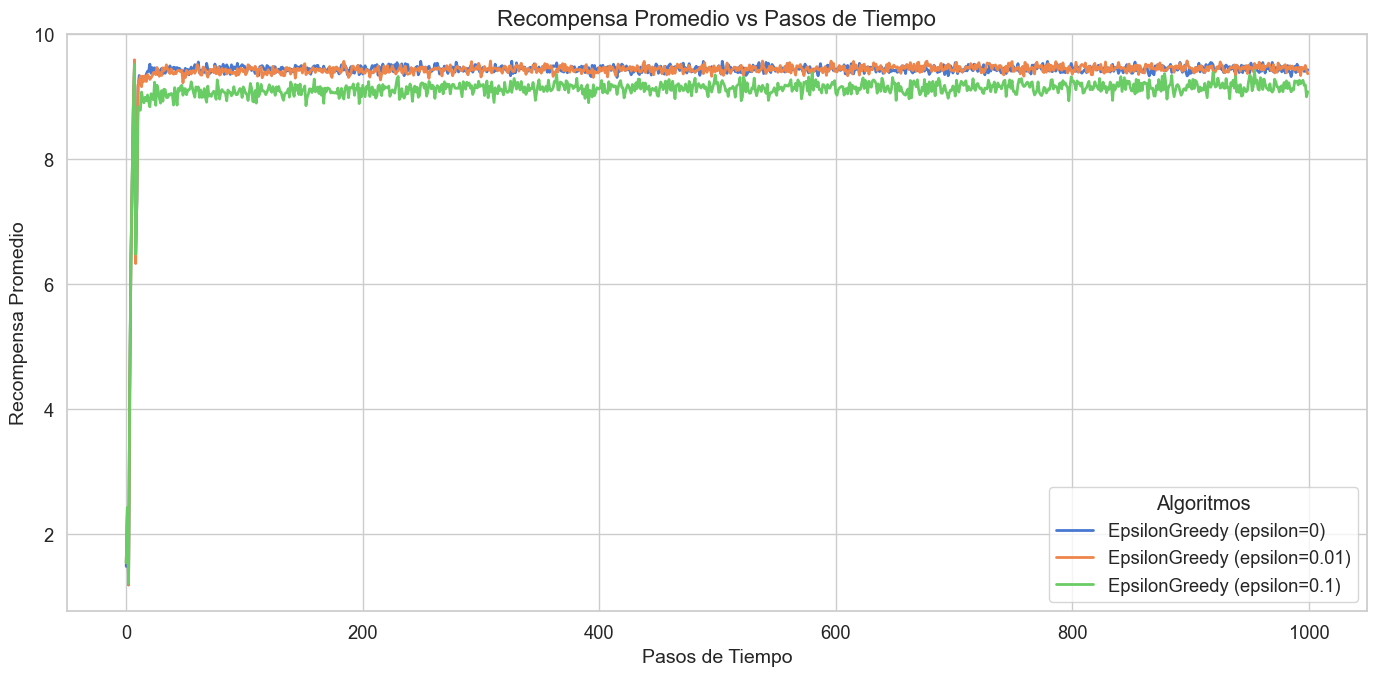

In [4]:

# Graficar los resultados
plot_average_rewards(steps, rewardsEpsilon, algorithmsEpsilon)


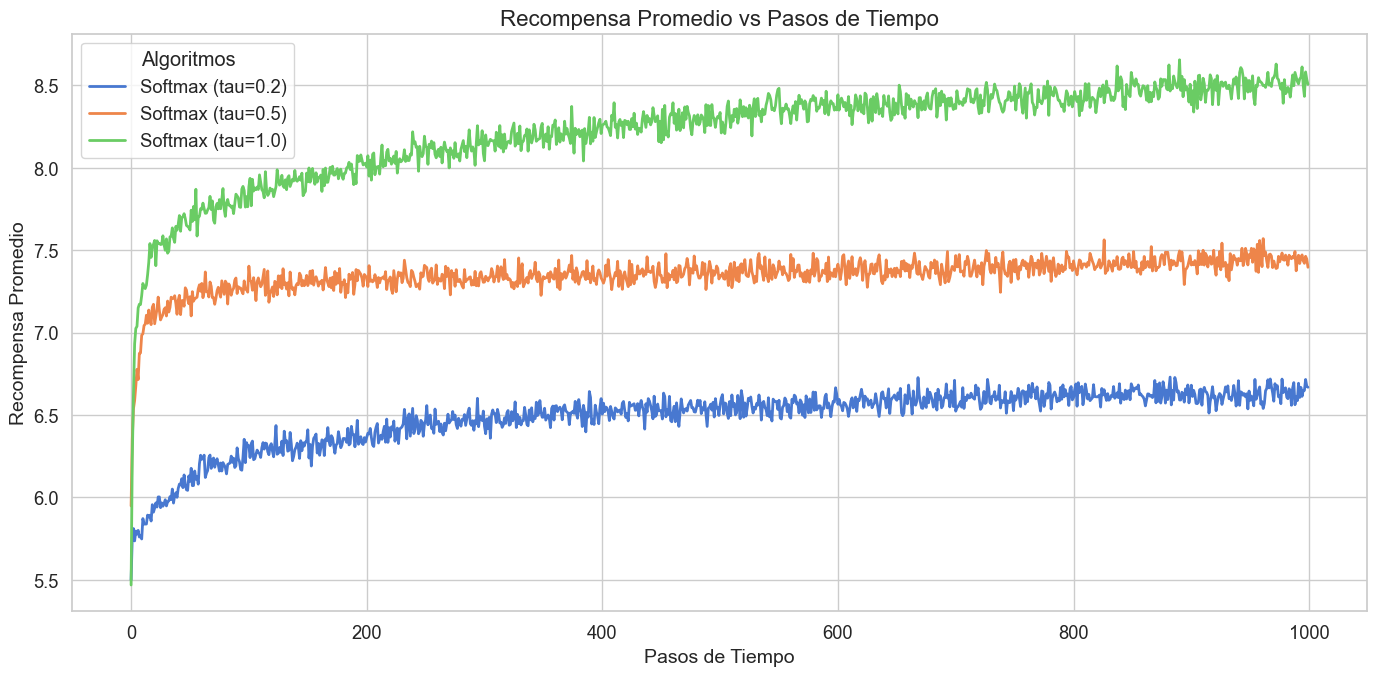

In [5]:

# Graficar los resultados
plot_average_rewards(steps, rewardsSoftmax, algorithmsSoftmax)

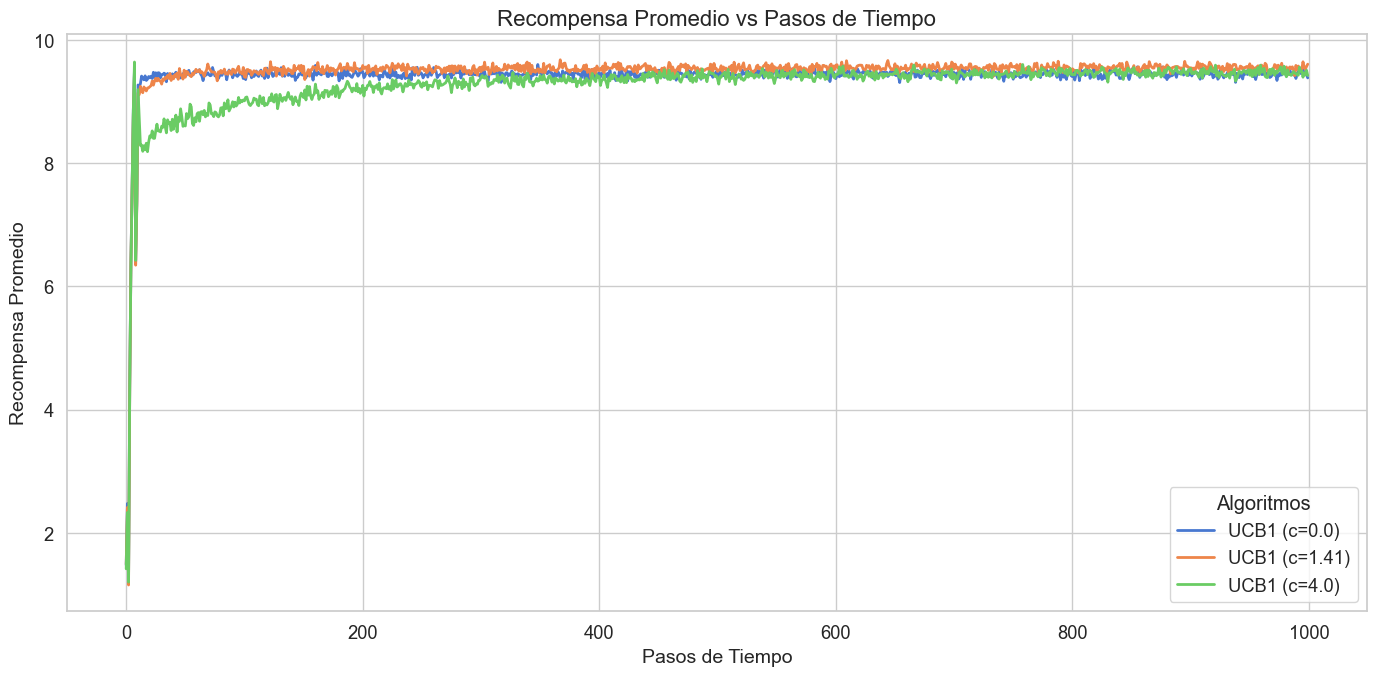

In [6]:

# Graficar los resultados
plot_average_rewards(steps, rewardsUCB1, algorithmsUCB1)

### Análisis detallado sobre la recompensa promedio vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido normal. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo:

1. **Crecimiento de la recompensa promedio en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En el entorno **Normal**, podemos ver que tanto la línea **azul (ε=0)** como línea **naranja (ε=0.01)**, alcanzan los valores más altos. Esto sugiere que la separación entre las medias de los brazos podría ser lo suficientemente grande como para que incluso una estrategia puramente **explotadora** logre identificar el óptimo con relativa facilidad.

   Por el contrario, en la línea **verde (ε=0.1)**, podemos ver una recompensa promedia inferior al resto, haciéndonos ver que una exploración del 10% no aporta suficiente ventaja frente a la **explotación** pura o una **exploración** mínima en este escenario concreto, posiblemente sea debido a que añadir un poco de **exploración** hace que el algoritmo introduzca pequeñas pérdidas acumuladas sin mejorar el proceso de identificación el óptimo.

2. **Crecimiento de la recompensa promedio en el algoritmo Softmax:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $\tau$, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva, debido al funcionamiento del algoritmo.

   - La línea **verde ($\tau$=1.0)** alcanza rápidamente una recompensa promedio alta, lo que indica que la estrategia con mayor **exploración** facilita la interpretación temprana del óptimo en este escenario, haciendo que además tenga un crecimiento constante en la recompensa promedio, demostrando que el suavizado que adquiere con $\tau$ es bastante importante en este escenario.
   - La línea **naranja ($\tau$=0.5)** también muestra un crecimiento, pero más lento en comparación con $\tau$=1.0, haciendo que con el suavizado equilibrado que introducimos aumento la recompensa promedio, pero de manera más sostenida.
   - La línea **azul ($\tau$=0.2)** se mantiene en un nivel bajo de recompensa, lo que sugiere no haber mejoría en la tasa de recompensa promedio debido a su baja **exploración**.

3. **Crecimiento de la recompensa promedio en el algoritmo UCB1:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $c$, ya que obligatoriamente el algoritmo necesita seleccionar cada brazo al menos una vez para evitar una situación indefinida cuando el número de selecciones es cero, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En el entorno **Normal**, podemos ver que tanto la línea **azul c=0.0** como línea **naranja c=1.41**, alcanzan rápidamente los valores más altos, esto significa que en esta situación, tener una estrategia **explotadora**, aunque tenga un poco de **exploración** hace que el algoritmo encuentre rápidamente el óptimo, aunque la exploración de $c=1.41$ hace que tarde un poco más en encontrarlo debido a seleccionar otros brazos con menor valor estimado, esto sugiere que la separación de las medias de los brazos podrían ser lo suficiente grandes, luego vemos como las dos líneas se estabilizan con oscilaciones moderadas atribuibles a la varianza inherente de la distribución Normal.

   Por el contrario, en la línea **verde(c=4.0)**, podemos ver que cuando se separa de las otras dos líneas después de la fase de **exploración** inicial, tiene una recompensa promedio menor que la de las otras dos líneas, pero que alrededor del paso de tiempo 400 alcanza la recompensa promedio de las otras dos líneas, estabilizándose con oscilaciones moderadas atribuibles a la varianza inherente de la distribución Normal.

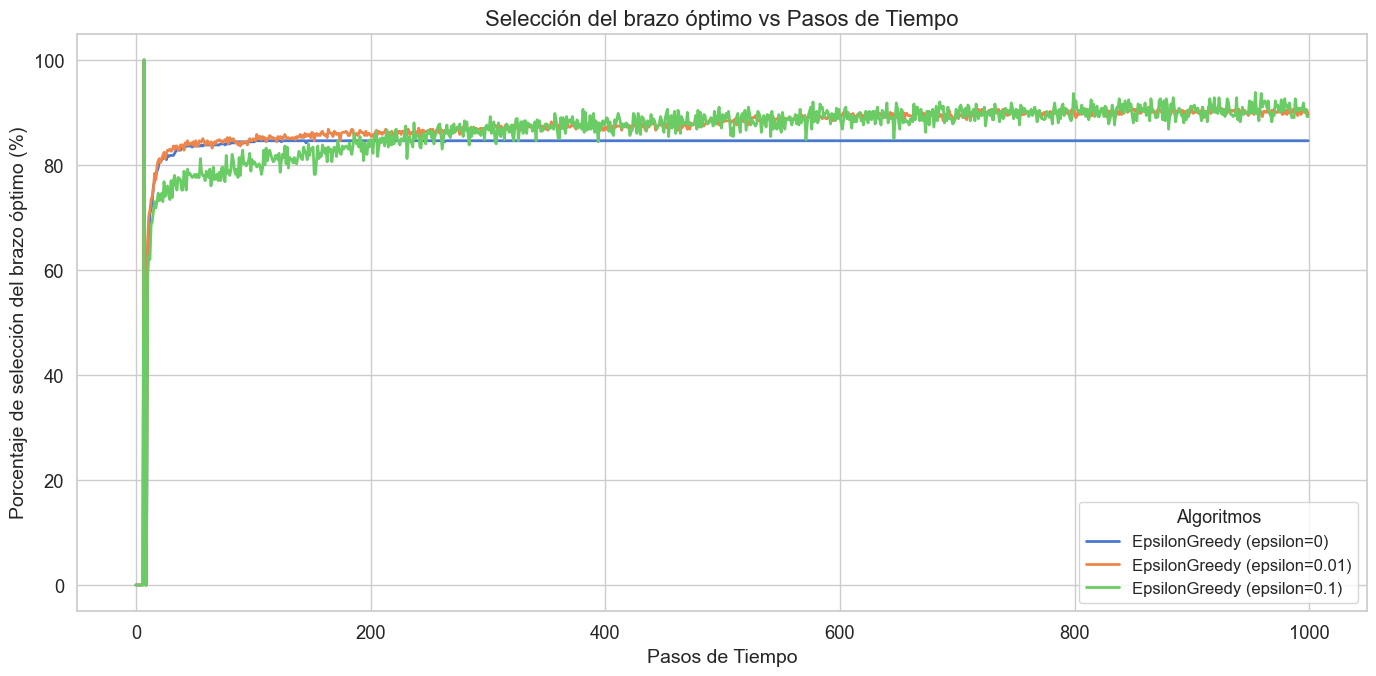

In [7]:
plot_optimal_selections(steps, optimal_selections_Epsilon, algorithmsEpsilon)

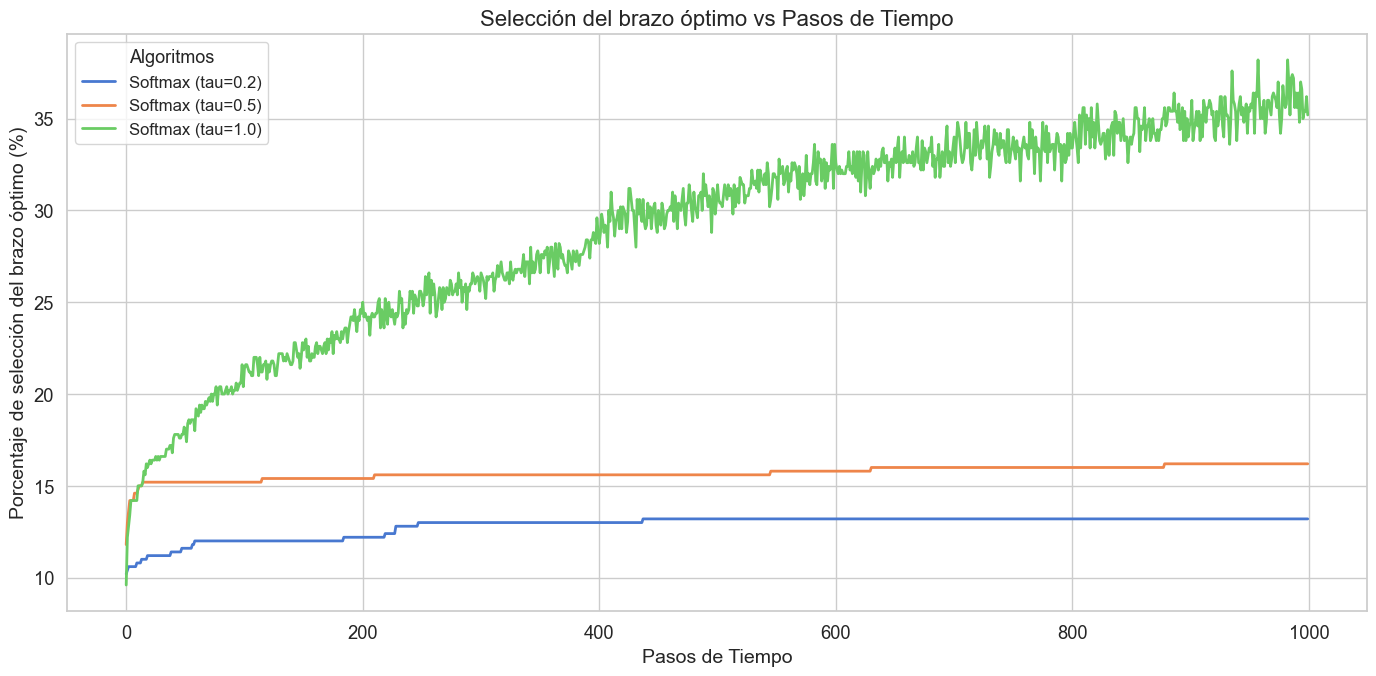

In [8]:
plot_optimal_selections(steps, optimal_selections_Softmax, algorithmsSoftmax)

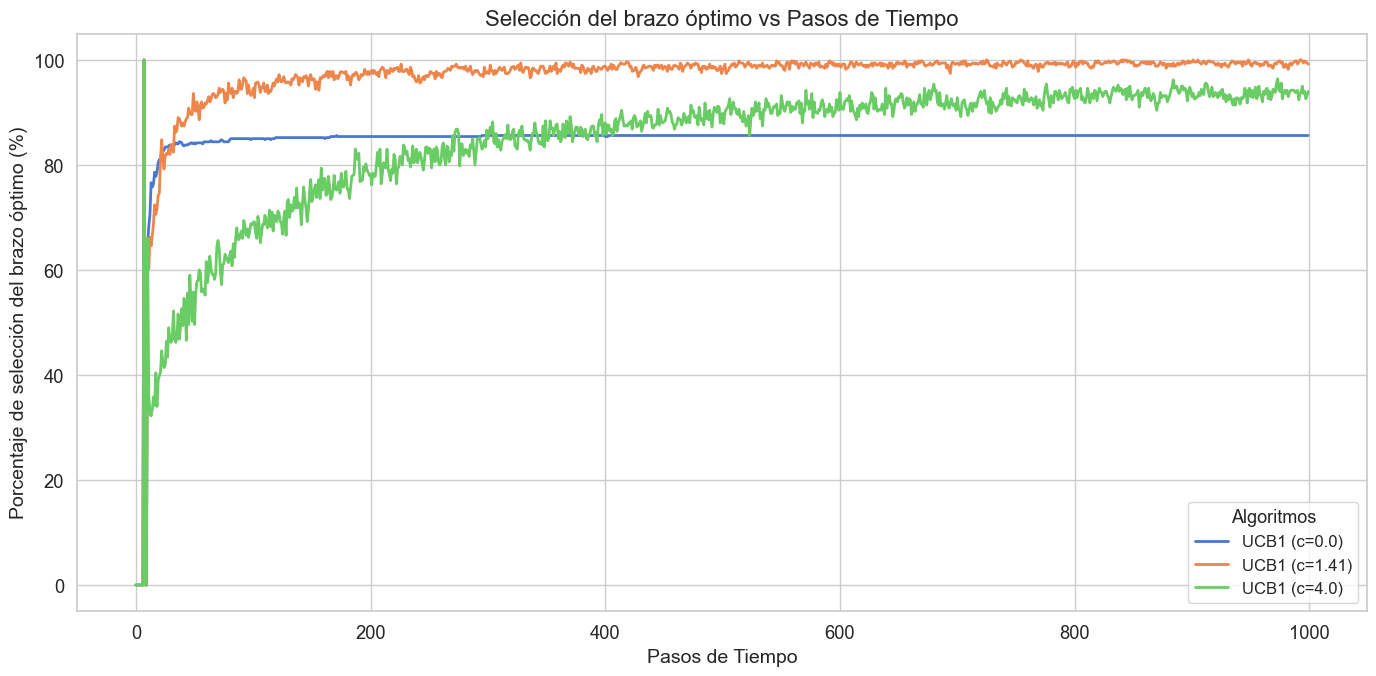

In [9]:
plot_optimal_selections(steps, optimal_selections_UCB1, algorithmsUCB1)

### Análisis detallado sobre la selección del brazo óptimo vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Selección del brazo óptimo vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido normal. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **porcentaje de selección del brazo óptimo** obtenido por cada algoritmo:

1. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En el entorno **Normal**, la línea **azul (ε=0)** se puede ver un aumento en la curva en los 50 primeros pasos de tiempo, seleccionando el brazo óptimo. Esto sugiere que la separación entre las medias de los brazos podría ser lo suficientemente grande como para que incluso una estrategia puramente **explotadora** logre identificar el óptimo con relativa facilidad. La línea después de los 50 primeros pasos por encima del 80% se mantiene debido a que al no incorporar exploración adicional, la probabilidad de corregir la estimación inicial es nula.

   La línea **naranja (ε=0.01)** en los 100 primeros pasos sigue la forma de la línea azul, aunque a diferencia de ésta, hay un ligero aumento posterior, esto es debido a que al haber un 1% de **exploración**, le permite ir encontrando con más facilidad el brazo óptimo.

   La línea **verde (ε=0.1)** tiene un peor comienzo que el resto debido a que al haber un 10% de **exploración** hace que el algoritmo seleccione otros brazos que no son los óptimos sobre todo al comienzo, pero luego demuestra que crece llegando al nivel de la línea naranja, demostrando de nuevo que en este caso, tener una componente de **exploración** favorece bastante el funcionamiento de este algoritmo.

2. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo Softmax:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $\tau$, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva, debido al funcionamiento del algoritmo.

   - La línea **verde ($\tau$=1.0)** demuestra tener un crecimiento muy superior en comparación con las otras dos líneas debido a que con esta alta exploración puede encontrar el brazo óptimo.
   - La línea **naranja ($\tau$=0.5)** al tener un componente de **exploración** más equilibrado, le cuesta mucho encontrar el brazo óptimo, por lo que tiene un crecimiento muy lento, dándonos a entender lo que la temperatura intermedia no genera suficiente presión hacia el brazo óptimo en este escenario.
   - La línea **azul ($\tau$=0.2)** sucede una situación parecida con la línea naranja pero con peor resultado y con apenas crecimiento, demostrando de nuevo que el componente de exploración en esta situación es muy importante a la hora de seleccionar el brazo óptimo.

3. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo UCB1:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $c$, ya que obligatoriamente el algoritmo necesita seleccionar cada brazo al menos una vez para evitar una situación indefinida cuando el número de selecciones es cero, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En la línea **naranja c=1.41**, se puede ver un gran crecimiento, haciendo que a partir del paso 200, la línea ronda entre el 95% y 100% de porcentaje de selección de brazo óptimo, que luego se va estabilizando en el 100%, demostrando un funcionamiento casi óptimo con esta configuración en este caso concreto, debido a que el algoritmo UCB1 está configurado con una estrategia de **exploración** equilibrada con **explotación**, coincidiendo con los otros dos algoritmos que para este caso, el porcentaje de selección del brazo óptimo funciona mucho mejor con tener una componente de **exploración**.

   La línea **verde(c=4.0)** aunque al principio selecciona pocas veces el brazo óptimo debido a su carácter de ir seleccionando varios brazos, luego experimento un crecimiento que a lo largo de los 1000 pasos de tiempo, la línea pasa de un 35% de selección de brazo óptimo a un 90%, demostrando así que aunque un componente **explorador** hace que le cueste al principio seleccionar el brazo óptimo, esto lo compensa haciendo que a lo largo de los pasos lo vaya seleccionando en una gran cantidad de veces.

   La línea **azul c=0.0** aunque los primeros 20 pasos mejora más que el resto seleccionando más veces en promedio el brazo óptimo, luego se atasca, esto es debido a que su carácter **explotador** hace que no reevalúe seleccionar otros brazos cuya estimación inicial era baja, haciendo que se atasque y sea la peor de las 3 líneas del algoritmo.

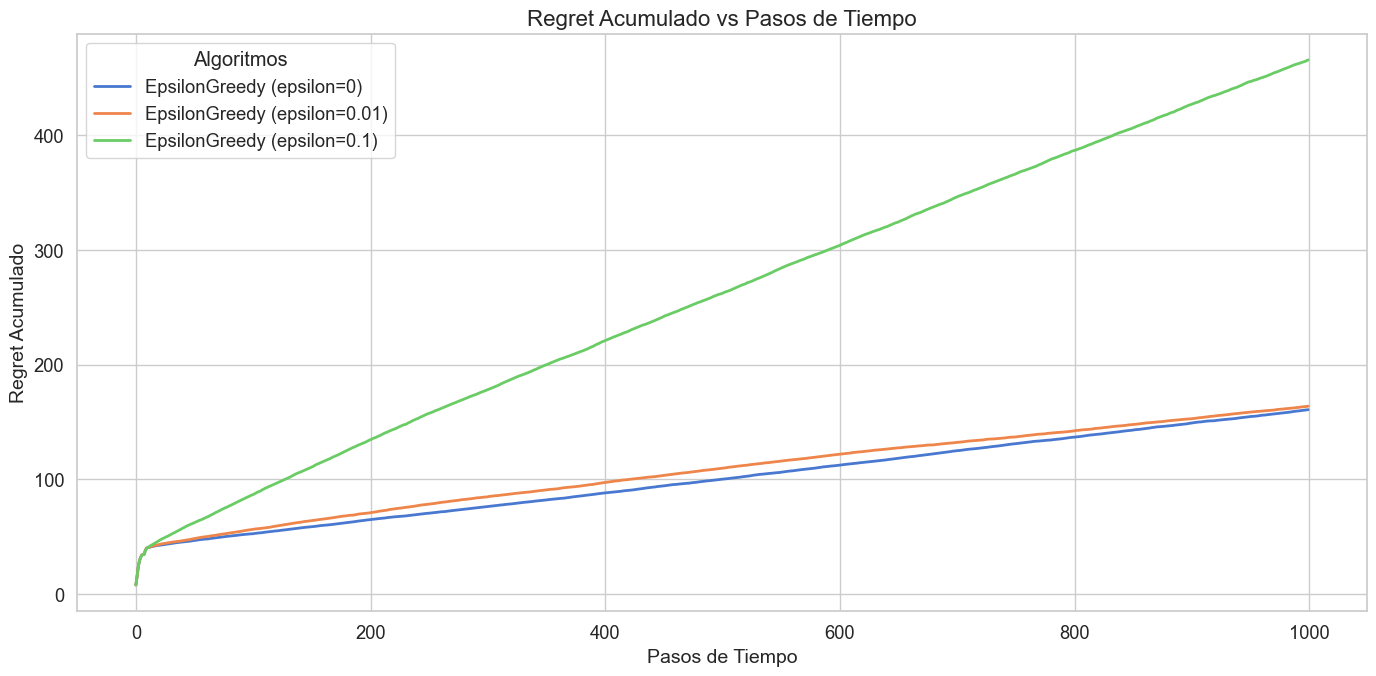

In [10]:
plot_regret(steps, regret_accumulated_Epsilon, algorithmsEpsilon)

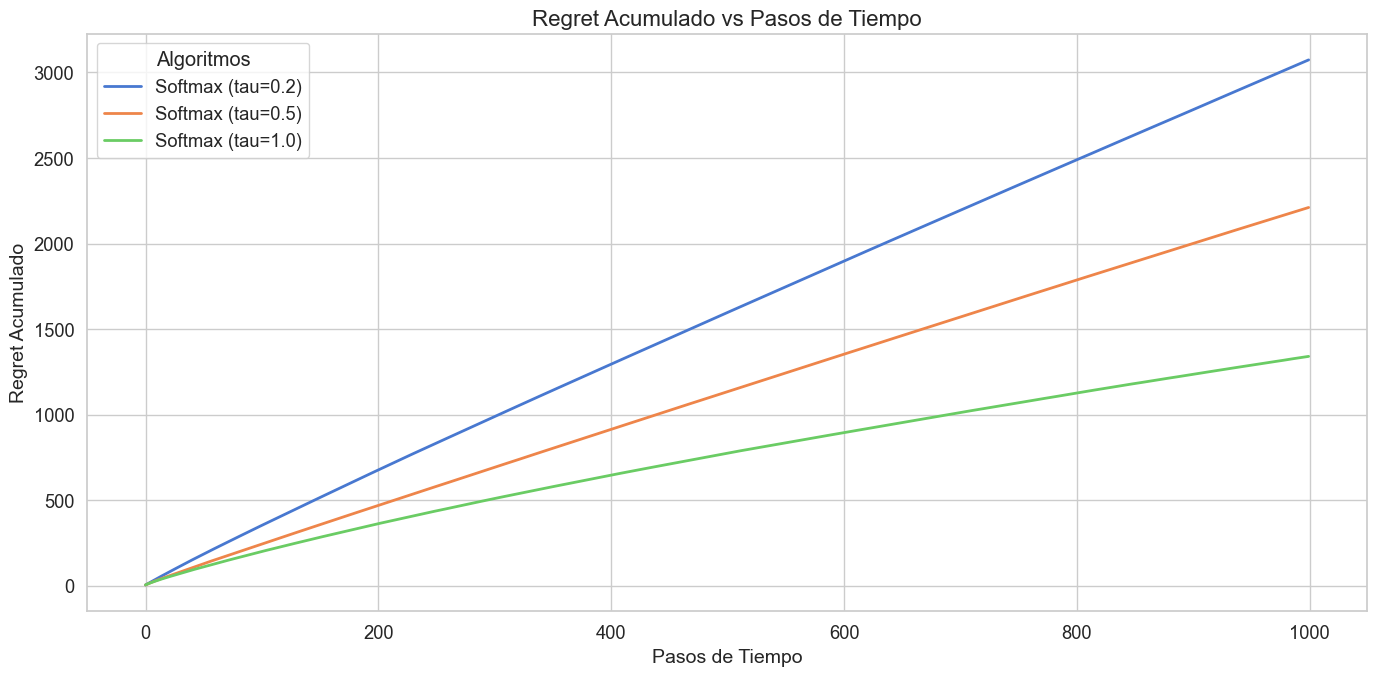

In [11]:
plot_regret(steps, regret_accumulated_Softmax, algorithmsSoftmax)

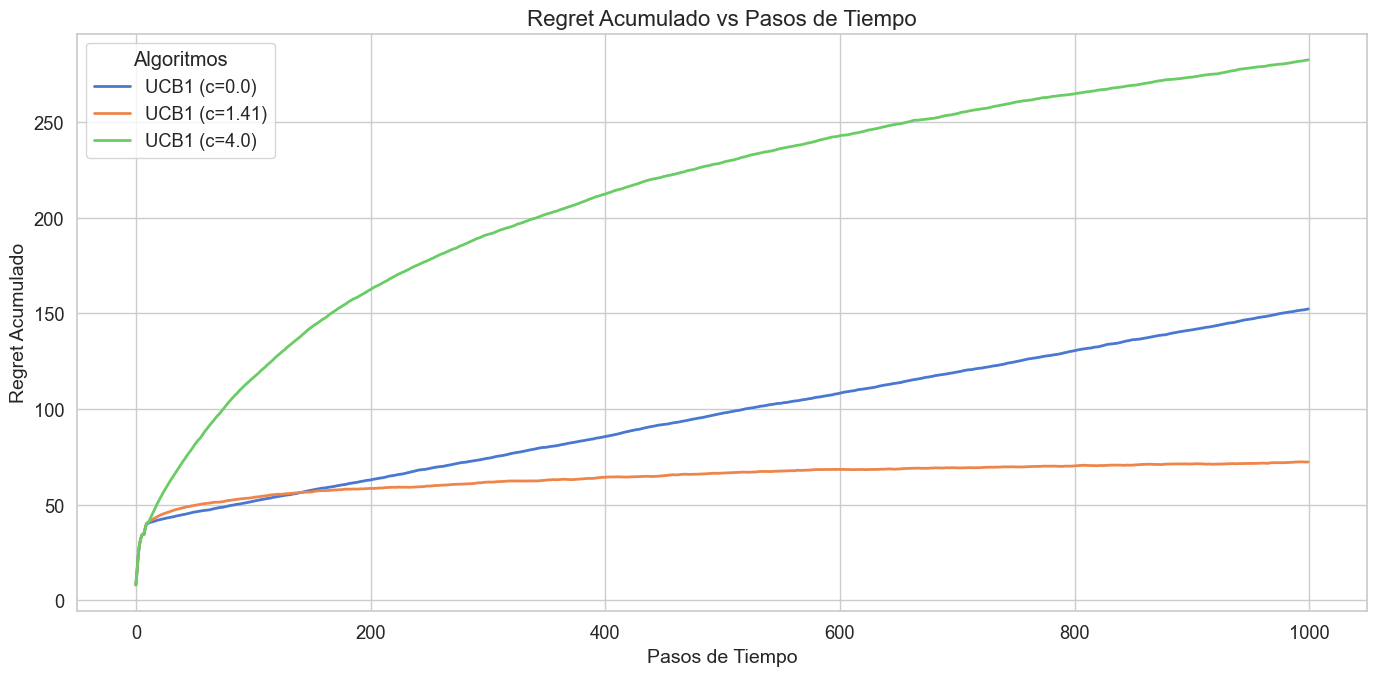

In [12]:
plot_regret(steps, regret_accumulated_UCB1, algorithmsUCB1)

### Análisis detallado sobre el regret acumulado vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Regret acumulado vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido normal. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **regret acumulado** obtenido por cada algoritmo:

1. **Crecimiento del regret acumulado en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva. Además se puede ver como el regret acumulado es poco más de 400, demostrando el correcto funcionamiento del algoritmo en esta situación.

   La línea **verde (ε=0.1)** demuestra un crecimiento más grande que las otras dos líneas debido a que era la línea que menos recompensa promedio tenía lo que hace que su lamento acumulado sea el más alto ya que su política de selección de brazos (10% de **exploración**), y que la forma de la línea sea una línea recta demuestra que la recompensa es constante aunque haya un aumento de selección óptima, que hace que se siga acumulando regret de manera estable a lo largo del tiempo.

   La línea **naranja (ε=0.01)** y la línea **azul (ε=0)** se puede ver como las líneas empiezan juntas, se separan poco después para juntarse de nuevo después de 1000 pasos de tiempo, demostrando que su recompensa promedio es muy parecida, lo que hace que su lamento acumulado también lo sea. Aunque si miramos su gráfica de selección de brazo óptimo se pueda ver un aumento en la línea naranja con respecto a la azul que se mantiene, haciéndonos ver que aunque seleccione más veces el brazo óptimo, también está cogiendo brazos que son peores en recompensa promedio cuando no selecciona el óptimo, viendo como luego se juntan las dos líneas demuestra que la pendiente en la línea naranja va decreciendo y esto hace que posiblemente la línea naranja pueda ser mejor que la línea azul.

2. **Crecimiento del regret acumulado en el algoritmo Softmax:**

   - La línea **azul ($\tau$=0.2)** demuestra que su regret acumulado es muy alto debido a que al ser una estrategia explotadora, su recompensa promedio es muy baja y su selección de brazo óptimo también sea la peor de las 3 líneas, lo que hace que elija los peores brazos en términos recompensa y que le sea muy complicado explorar otros brazos con una menor estimación inicial para encontrar mejores brazos subóptimos e incluso el brazo óptimo.
   - La línea **naranja ($\tau$=0.5)** tiene un crecimiento de lamento acumulado menor que la de la línea azul, haciendo que sea mucho mejor en recompensa promedio y en la selección de brazo óptimo, esto es debido a su constante crecimiento en estos dos ámbitos lo que tiene sentido que sea mejor estrategia la del equilibrio **exploración** y **explotación** que solo **explotación** en este caso. 
   - La línea **verde ($\tau$=1.0)** sucede un caso muy parecido al de la línea naranja, puesto que su recompensa promedio esta en crecimiento y su selección de brazo óptimo también, demuestra que la **exploración** en este algoritmo beneficia mucho su bajo lamento acumulado.

3. **Crecimiento del regret acumulado en el algoritmo UCB1:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $c$, ya que obligatoriamente el algoritmo necesita seleccionar cada brazo al menos una vez para evitar una situación indefinida cuando el número de selecciones es cero, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   La línea **verde(c=4.0)** se ve que aunque tenga mas regret acumulado que las otras dos líneas, la pendiente de la linea empieza a decrecer a lo largo de los pasos de tiempo, esto es debido al incremento de su ganancia promedio y su aumento en la selección del brazo óptimo, haciendo que la estrategia **exploradora** ayude a revalorizar valores estimados iniciales que de primeras parecían bajos pero que pueden resultar útiles si se les da más oportunidades.

   La línea **azul c=0.0** experimenta un crecimiento incremental debido a que en su ganancia máxima permanece constante y en su selección de brazo óptimo también por lo que al ser una estrategia **explotadora**, no le da oportunidad a otros brazos con valor estimado inferior, lo que hace que casi nunca busque explorar otros brazos con la esperanza de seleccionar el brazo óptimo.

   En la línea **naranja c=1.41**, se puede ver que el crecimiento muy lento, lo que nos quiere decir que tanto en la recompensa promedio adquiere muy buenos valores, además de que en la selección de brazos converge al óptimo lo que hace que el regret experimente incrementos casi irrisorios debido tanto a su recompensa promedio como selección del brazo óptimo.

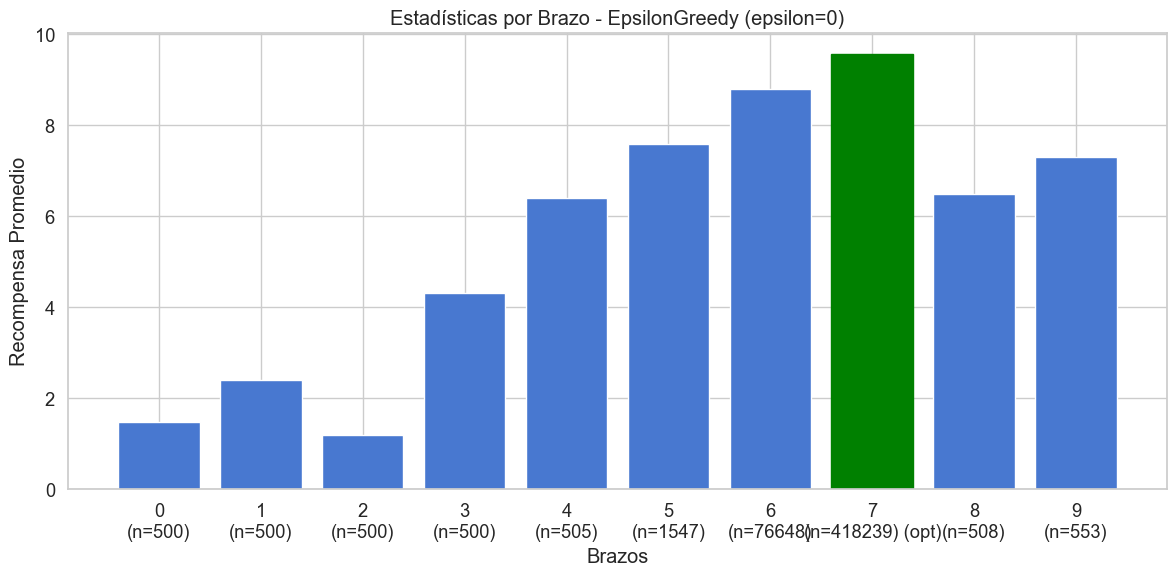

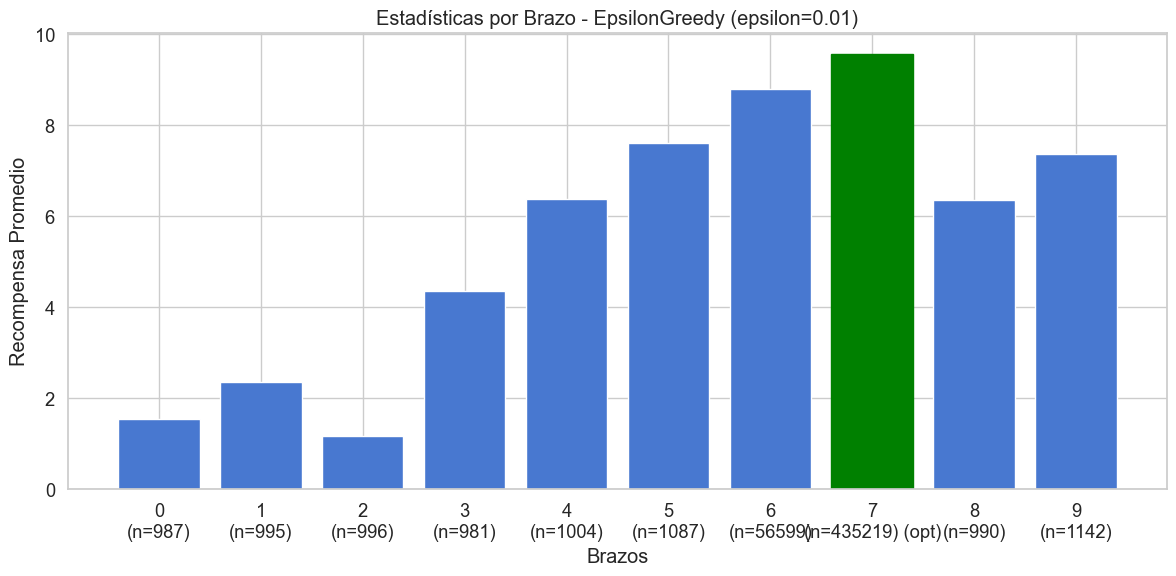

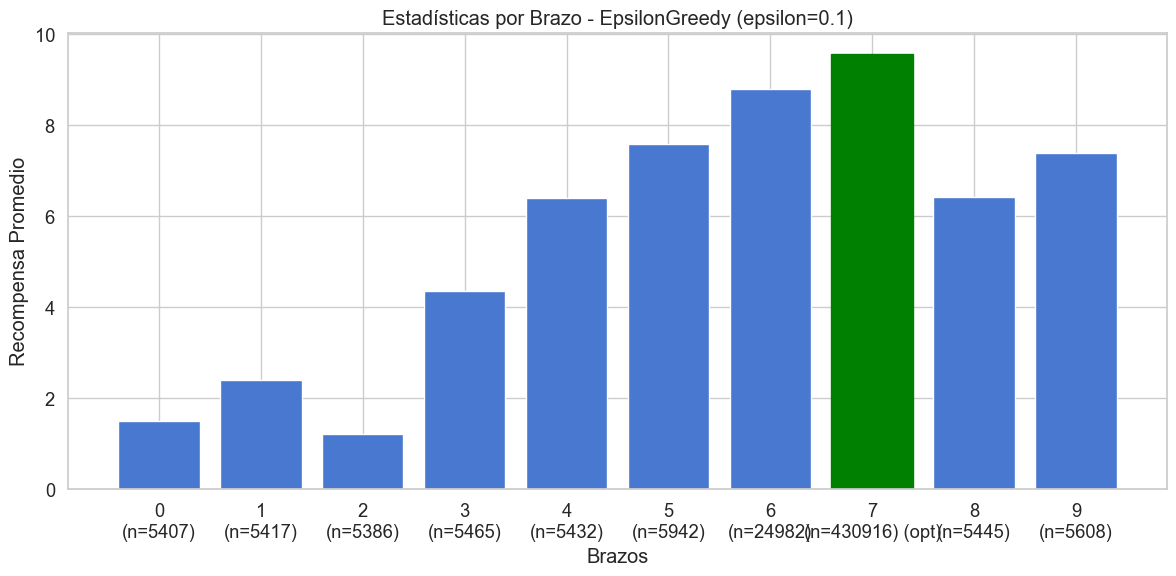

In [13]:
plot_arm_statistics(arm_stats_Epsilon, algorithmsEpsilon)

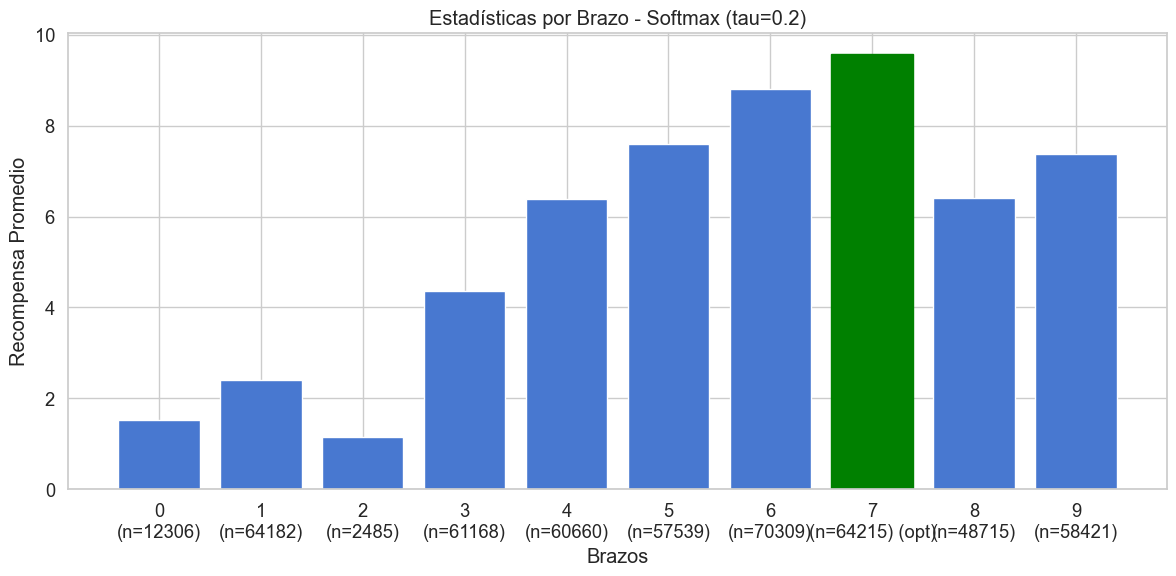

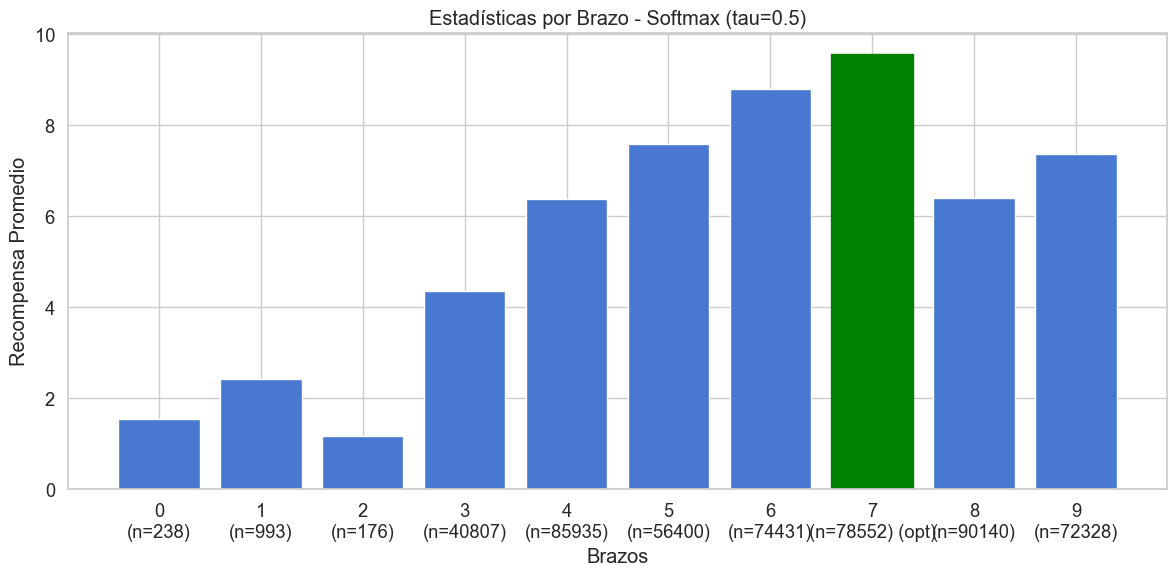

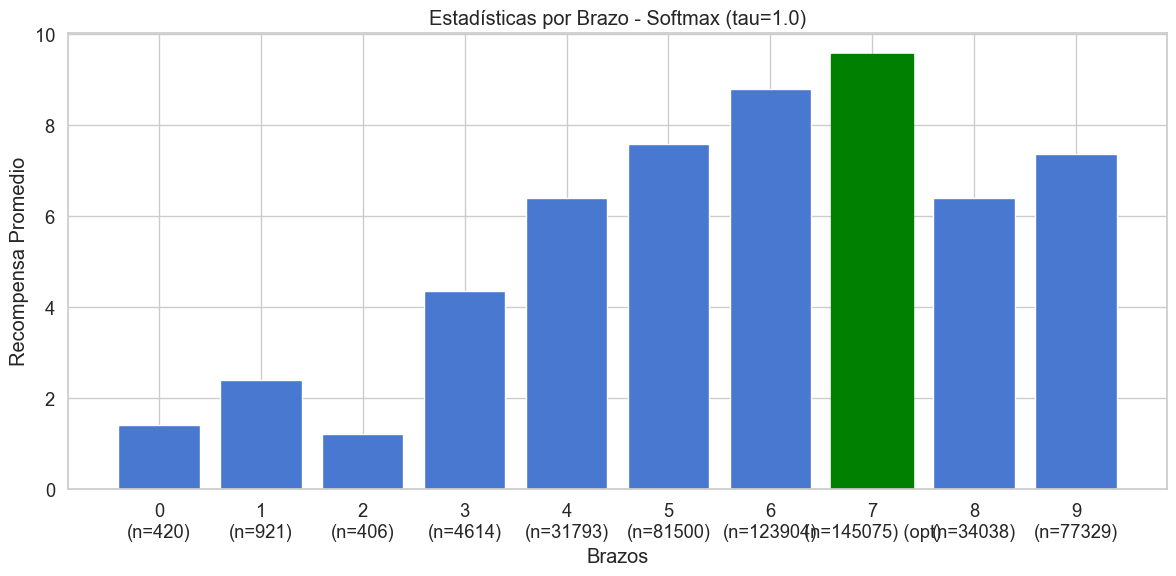

In [14]:
plot_arm_statistics(arm_stats_Softmax, algorithmsSoftmax)

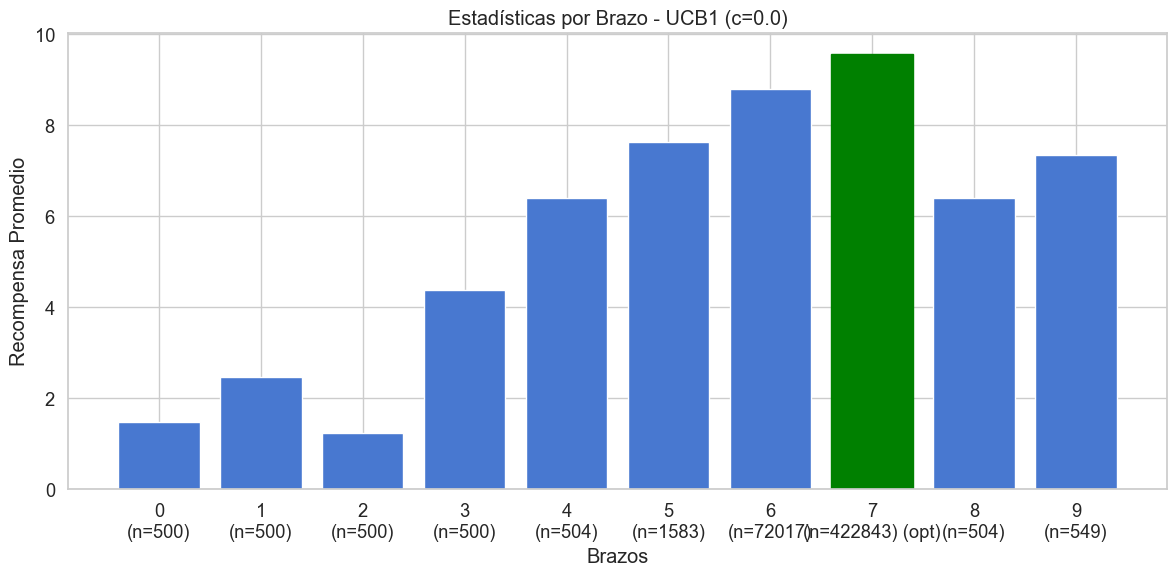

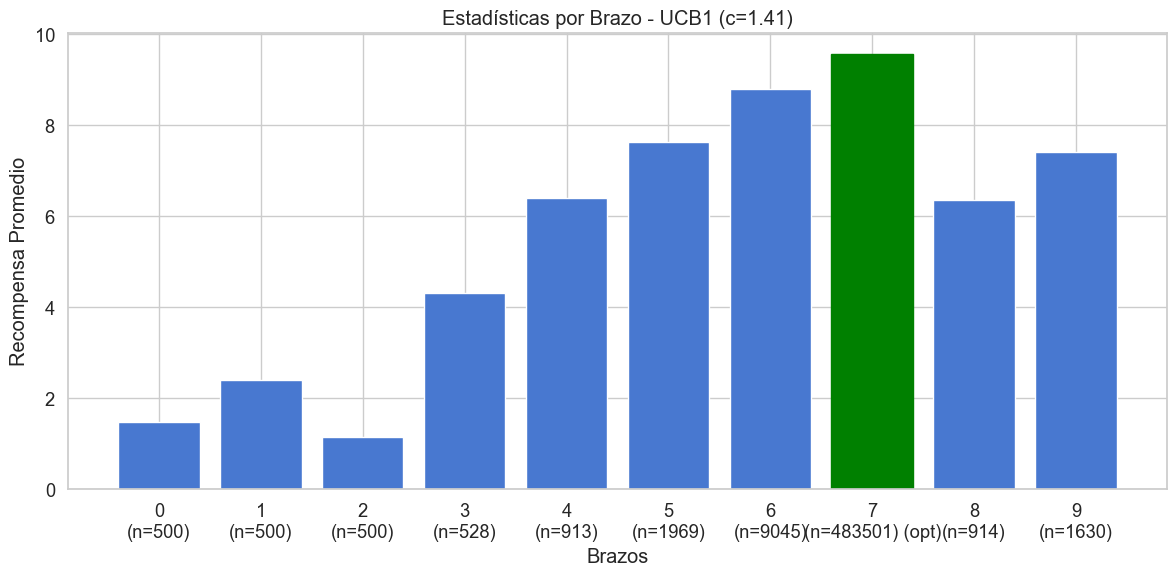

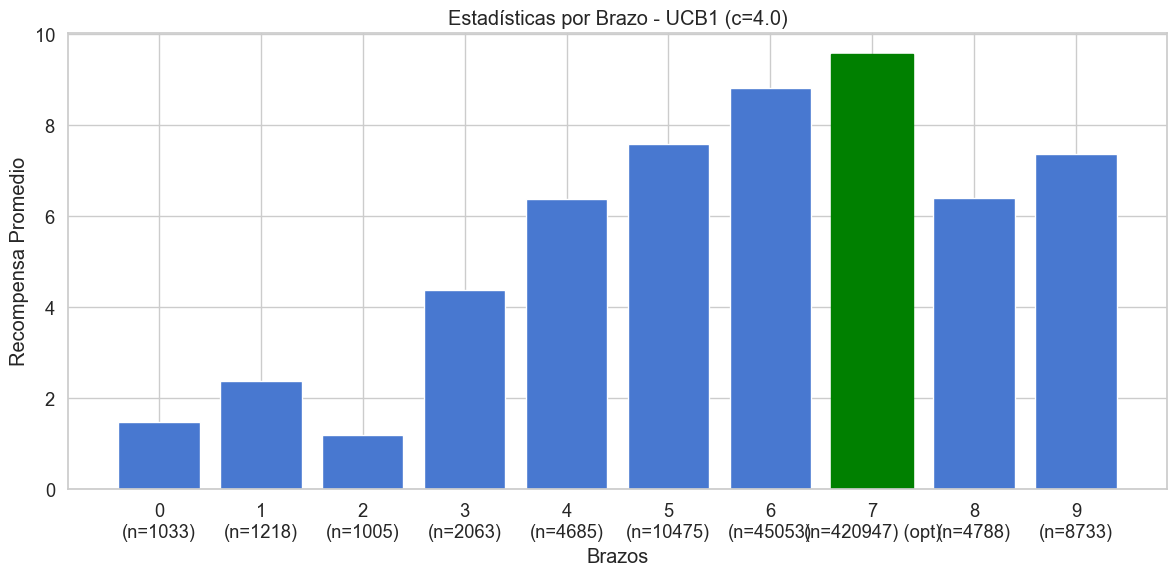

In [15]:
plot_arm_statistics(arm_stats_UCB1, algorithmsUCB1)

### Análisis detallado sobre las estadísticas por brazo

Las imágenes muestran un histograma titulado **"Estadísticas por Brazo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido normal. En el eje **x** se representan los **brazos**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada brazo en cada algoritmo. Hay que tener en cuenta que cada algoritmo con cada configuración es ejecutado 500000 veces, en las cuales la recompensa promedio no variará entre gráficas ya que no es un valor influenciado por el tipo de algoritmo, además colorearemos con color verde el brazo con mayor recompensa promedio para que sea más fácil de visualizar. También tener en cuenta que elegimos el brazo 7 como óptimo porque es el que mayor media tiene, siendo el siguiente brazo con mayor media el brazo 6. Ahora hablaremos de las estadísticas de cada brazo por cada algoritmo dependiendo de su ε, $\tau$ y $c$:

1. **Estadísticas por brazo en el algoritmo ε-Greedy:**

   En **ε=0** podemos ver como el algoritmo ha seleccionado 418239 veces el brazo óptimo y 76648 el algoritmo subóptimo con más recompensa promedio, haciéndonos ver que en un 98.98% de las veces se elegirá entre el óptimo o el siguiente más óptimo, siendo un 83.65% las veces que elige el brazo más óptimo lo que representa que esta estrategia **explotadora** hace mucho uso del brazo óptimo y subóptimo.

   En **ε=0.01** se selecciona el brazo óptimo 435219 veces y el siguiente más óptimo 56599 veces, siendo un 98.36% de las veces que se selecciona el brazo más óptimo o subóptimo y un 87.04% de veces que elige el brazo más óptimo lo que nos permite ver que con una **exploración** del 1% aunque se seleccionen más veces otros brazos con menor recompensa promedio, también selecciona más veces el brazo óptimo que con la estrategia puramente **explotadora** sugiriendo que seleccionar otros brazos con menor valor estimado, aumenta también las veces que se selecciona el brazo óptimo.

   En **ε=0.1** se puede ver como se selecciona el brazo óptimo 430916 veces y el siguiente brazo más óptimo, 24982 veces, siendo un 91.18% de las veces que elegirá el brazo más óptimo o más subóptimo dependiendo de la recompensa promedio y un 86.18% las veces que se selecciona el brazo más óptimo. Esto nos sugiere que aunque se seleccione más veces el brazo óptimo con respecto a la estrategia con **explotación**, al tener un 10% de **exploración** hace que explore bastante veces otros brazos con menor recompensa promedio con respecto a la configuración elitista. 

2. **Estadísticas por brazo en el algoritmo Softmax:**

   En $\tau$=0.2 vemos como se selecciona 62415 el brazo óptimo y 70309 el brazo subóptimo con mayor recompensa promedio, siendo esto un 26.54% de selección para el brazo óptimo y subóptimo y un 12.48% la selección del brazo óptimo. Softmax con τ=0.2 es una estrategia bastante **explotadora**, por lo que depende fuertemente de las estimaciones iniciales. Si estas no reflejan correctamente la recompensa real de los brazos, el algoritmo puede quedar atrapado en brazos subóptimos durante gran parte de la ejecución.

   En $\tau$=0.5 el brazo óptimo se selecciona 78552 veces y el brazo más subóptimo en recompensa promedio un 74431 veces, siendo un  30.6% de las veces que se selecciona el brazo óptimo y subóptimo y un 15.71% de las veces que elige el brazo más óptimo. Con esto podemos ver como el algoritmo mejora en este caso al tener una estrategia más **exploradora** permitiendo que el algoritmo seleccione más veces el brazo óptimo y subóptimo.

   En $\tau$=1.0 se puede ver como el brazo óptimo se selecciona 145075 veces y el brazo más subóptimo 123904 siendo esto un 53.80% de veces que se selecciona el brazo óptimo y subóptimo y un 29.01% las veces que se selecciona el brazo óptimo. Esto justifica una vez más lo que hemos visto con $\tau$=0.5, que el algoritmo funciona mejor cuanto mayor **exploración** haga, lo que permite seleccionar brazos con menor valor estimado permitiendo encontrar con más facilidad los brazos con mayor recompensa promedio.

3. **Estadísticas por brazo en el algoritmo UCB1:**

   En c=0.0 vemos como el brazo óptimo se selecciona 422843 veces y el brazo subóptimo 72017 veces, siendo esto un 98.97% de las veces que se selecciona el brazo óptimo y subóptimo y un 84.57% de las veces que se selecciona el brazo óptimo. Esto nos permite ver que el algoritmo con carácter mayormente **explotador** selecciona gran parte de las veces el algoritmo óptimo y subóptimo debido a que estos brazos tendrán una gran valor estimado que permite al algoritmo utilizarlos muchas veces.

   En c=1.41 se selecciona el brazo óptimo 483401 y el brazo subóptimo 9045 veces, siendo esto un 98.49% de las veces que se selecciona el brazo óptimo y subóptimo, y un 96.68% las veces que selecciona el brazo óptimo. Esto indica que el algoritmo va convergiendo hacia el brazo más óptimo con este equilibrio de **exploración** y **explotación** pudiendo encontrar y seleccionar el óptimo con bastante facilidad.

   En c=4.0 podemos ver como se selecciona 420947 veces el brazo óptimo y 45053 veces el brazo subóptimo, siendo esto un 93.2% de las veces que el algoritmo selecciona el brazo óptimo y subóptimo y un 84.19% de las veces que selecciona el brazo óptimo. Aquí podemos observar que pese a tener una mayor **exploración** con esta configuración el algoritmo UCB1 se seleccionan menos veces el brazo óptimo y subóptimo.

## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)** con el tipo de bandidos **Normal**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado en el estudio del algoritmo epsilon-greedy, softmax y UCB1, llegando a las siguientes conclusiones a partir de los resultados obtenidos y la gráficas generadas:

### **1. Epsilon-greedy**
Hemos visto que el algoritmo epsilon-greedy en esta situación prefiere tener un comportamiento **explotador** más que **explorador** ya que con los valores estimados iniciales el algoritmo puede encontrar con relativa facilidad los brazos con mayor recompensa promedio, encontrando así también el brazo óptimo y el mas subóptimo, por lo que si el algoritmo tiene una configuración completamente elitista o se le una **exploración** del 1% el algoritmo no se desviará a otros brazos con menor recompensa promedio.

### **2. Softmax**
En este caso, el algoritmo muestra un mejor comportamiento conforme aumenta su temperatura lo que hace que el algoritmo **explore** encontrando así brazos con mejor recompensa promedio, esto se debe a que el algoritmo empieza con un bajo valor estimado sobre los brazos óptimos y subóptimo lo que hace que al tener una temperatura baja haya menos probabilidades de explorar que con temperatura alta, por lo que se estanca en brazos con mayor valor estimado que son brazos con menor recompensa promedio.


### **3. UCB1**
En cuanto al algoritmo UCB1, muestra que con un coeficiente bajo y equilibrado son los que mejor funcionan lo que hace que el algoritmo da a los brazos óptimos un valor estimado alto y con ello seleccionar los brazos óptimos sin necesidad de seleccionar otros brazos con valores estimados iniciales menores.

### **Comparación entre algoritmos**

Si comparamos los 3 algoritmos podemos ver que el algoritmo que mejor funciona para este experimento es el algoritmo UCB1 ya que tiene una muy buena recompensa promedio entre todas sus configuraciones, su selección de brazo óptima es la mejor entre los 3 algoritmos. su regret acumulado es el más bajo y tiene un porcentaje de uso de brazo óptimo muy bueno comparable a epsilon-greedy